<a href="https://colab.research.google.com/github/vikash000x/vision_transformer-and-nanoVLM/blob/main/NanoVLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

imports

In [323]:
import math, random
import torch, torch.nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

variables

In [324]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 32
EMBED_DIM = 64
ATTENTION_HEADS = 4
BATCH_SIZE = 12
EPOCHS = 50
LR = 1e-3
TEMPERATURE = 0.07

synthetic dataset properties

In [325]:
colors = ['red', 'green', 'blue', 'yellow', 'orange', 'pink', 'brown', 'gray']
shapes = ['square', 'circle', 'triangle']
positions = ['left', 'center', 'right', 'top', 'bottom', 'top-left', 'top-right', 'bottom-left', 'bottom-right']


draw the image

In [326]:
def draw_sample(color, shape, position, img_size= IMG_SIZE):
  img = Image.new('RGB', (img_size, img_size), color= 'white')
  draw = ImageDraw.Draw(img)

  margin = 6
  h = w = img_size - 2 * margin
  if 'left' in position:
    x0 = margin
    x1 = margin + w//2
  elif 'right' in position:
    x0 = margin + w//2
    x1 = img_size - margin
  elif 'top-left' in position:
    x0 = margin
    x1 = margin + w//2
  elif "bottom-left" in position:
    x0 = margin
    x1 = margin + w//2
  elif "top-right" in position:
    x0 = margin + w//2
    x1 = img_size - margin
  elif "bottom-right" in position:
    x0 = margin + w//2
    x1 = img_size - margin
  else:
    x0 = margin + w//4
    x1 = margin + 3*w//4



  if 'top' in position:
    y0 = margin
    y1 = margin + h//2
  elif 'top-left' in position:
    y0 = margin
    y1 = margin + h//2
  elif "bottom-left" in position:
    y0 = margin + h//2
    y1 = img_size - margin
  elif "top-right" in position:
    y0 = margin
    y1 = margin + h//2
  elif "bottom" in position:
    y0 = margin + h//2
    y1 = img_size - margin
  elif "bottom-right" in position:
    y0 = margin + h//2
    y1 = img_size - margin
  else:
    y0 = margin + h//4
    y1 = margin + 3*h//4

  if shape == 'circle':
    draw.ellipse([x0, y0, x1, y1], fill= color, outline='black')
  elif shape == 'square':
    draw.rectangle([x0, y0, x1, y1], fill= color, outline='black')
  else:
    draw.polygon([(x0, y0), (x1, y1), (x0, y1)], fill= color, outline='black')

  return img



class for building the dataset- Images and Captions

In [327]:
class ShapesDataset():
  def __init__(self):
    self.images = []
    self.captions = []

    for c in colors:
      for s in shapes:
        for p in positions:
          img = draw_sample(c, s, p)
          cap = f"{c} {s} {p}"

          # Fix the UserWarning by making a copy of the numpy array
          self.images.append(torch.from_numpy(np.asarray(img).copy()).permute(2,0,1).float()/255.0)
          self.captions.append(cap)


    self.vocab, self.word2idx = self.build_vocab(self.captions)

  def build_vocab(self, texts):
    words = sorted({w for t in texts for w in t.split()})
    vocab = ['[CLS]'] + words
    w2i = {w:i for i,w in enumerate(vocab)}
    return vocab, w2i

  def encode_text(self, text):
    toks = [self.word2idx['[CLS]']] + [self.word2idx[w] for w in text.split()]
    return torch.tensor(toks, dtype=torch.long)

  def __getitem__(self, idx):
    return self.images[idx], self.encode_text(self.captions[idx]), self.captions[idx]

  def __len__(self):
    return len(self.images)

create full dataset

In [328]:
full_ds = ShapesDataset()
VOCAB_SIZE = len(full_ds.vocab)
print(VOCAB_SIZE)
print(full_ds.vocab)

21
['[CLS]', 'blue', 'bottom', 'bottom-left', 'bottom-right', 'brown', 'center', 'circle', 'gray', 'green', 'left', 'orange', 'pink', 'red', 'right', 'square', 'top', 'top-left', 'top-right', 'triangle', 'yellow']


train-val data creation

In [329]:
train_size = int(0.8*len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = torch.utils.data.random_split(full_ds, [train_size, val_size])

DataLoader

In [330]:
train_loader = DataLoader(train_ds, batch_size= BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_ds, batch_size = BATCH_SIZE, shuffle = False)

In [331]:
print("\n--- Verifying unique images per batch ---")
# Get a batch from the training loader
sample_imgs, _, _ = next(iter(train_loader))

# Convert each image in the batch to a hashable format (e.g., flattened tuple)
# This allows us to put them into a set to check for uniqueness.
unique_images = set()
for img_tensor in sample_imgs:
    # Convert tensor to numpy array, flatten, and then to a tuple
    # Using .cpu() in case the tensor is on GPU
    unique_images.add(tuple(img_tensor.cpu().numpy().flatten()))

# Check if the number of unique images equals the batch size
if len(unique_images) == BATCH_SIZE:
    print(f"All {BATCH_SIZE} images in the sample batch are unique.")
else:
    print(f"Found duplicate images in the sample batch! {len(unique_images)} unique out of {BATCH_SIZE}.")
print("----------------------------------------")


--- Verifying unique images per batch ---
All 12 images in the sample batch are unique.
----------------------------------------


display a sample data point

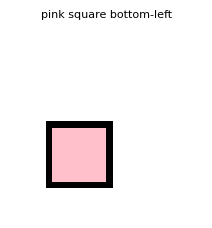

In [332]:
imgs, encoded_caps, _ = next(iter(train_loader))
idx = random.randint(0, BATCH_SIZE-1)
img = (imgs[idx].permute(1,2,0).numpy()*255).astype(np.uint8)

caption_tokens = encoded_caps[idx].tolist()
caption = " ".join([full_ds.vocab[token] for token in caption_tokens if token in range(len(full_ds.vocab))])
caption = caption.replace('[CLS] ', '')

plt.figure(figsize=(2.5, 2.5))
plt.imshow(img)
plt.title(caption, fontsize=8)
plt.axis('off')
plt.show()

image encoder

In [333]:
import torch.nn as nn

class ImageEncoder(nn.Module):
  def __init__(self, embed_dim = EMBED_DIM):
    super().__init__()
    self.convolutions = nn.Sequential(
        nn.Conv2d(3, 32, 3, 2, 1),
        nn.ReLU(),
        nn.Conv2d(32, 64, 3, 2, 1),
        nn.ReLU(),
        nn.Conv2d(64, 128, 3, 2, 1),
        nn.ReLU(),
        nn.Conv2d(128, 256, 3, 2, 1),
        nn.ReLU()

    )

    self.projection = nn.Linear(256, embed_dim)
    self.layernorm1 = nn.LayerNorm(embed_dim)

  def forward(self, x):
    x = self.convolutions(x)
    x = x.mean(dim = [2, 3])
    x = self.projection(x)
    x = F.normalize(self.layernorm1(x), dim=-1)
    return x

Text encoder

In [334]:
class TextEncoder(nn.Module):
  def __init__(self, embed_dim= EMBED_DIM, num_heads= ATTENTION_HEADS, vocab_size = VOCAB_SIZE, context_window=4):
    super().__init__()
    self.token_embedding = nn.Embedding(vocab_size, embed_dim)
    self.position_embedding = nn.Embedding(context_window, embed_dim)
    self.mha = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True) # Set batch_first=True
    self.projection = nn.Linear(embed_dim, embed_dim)
    self.norm = nn.LayerNorm(embed_dim)

  def forward(self, toks):
    N, L = toks.shape # N = batch_size, L = seq_len
    position_ids = torch.arange(L, device = toks.device).unsqueeze(0).expand(N, L)
    token_embeddings = self.token_embedding(toks) # (N, L, E)
    position_embeddings = self.position_embedding(position_ids) # (N, L, E)
    x = token_embeddings + position_embeddings # (N, L, E)

    # With batch_first=True, input (N, L, E) and output (N, L, E)
    attn_output, _ = self.mha(x, x, x)

    # Take the [CLS] token embedding (first token)
    x = attn_output[:, 0] # (N, E)

    x = self.projection(x)
    x = F.normalize(self.norm(x), dim=-1)
    return x

clip loss

In [335]:


def clip_loss(img_emb, txt_emb, temperature = TEMPERATURE):
  logits = img_emb @ txt_emb.T / temperature
  targets = torch.arange(img_emb.size(0), device= img_emb.device)
  loss_i = F.cross_entropy(logits, targets)
  loss_t = F.cross_entropy(logits.T, targets)
  return ((loss_i + loss_t)/ 2.0)

model, data, optimizer

In [336]:
img_enc = ImageEncoder().to(device)
text_enc = TextEncoder().to(device)
params = list(img_enc.parameters()) + list(text_enc.parameters())
optimizer = torch.optim.AdamW(params,  lr = LR)

In [337]:
def show_image(t, title= None):
  img = (t.permute(1, 2, 0).numpy()*255).astype(np.uint8)
  plt.figure(figsize=(2.2,2.2))
  plt.axis('off')
  if title: plt.title(title, fontsize = 8)
  plt.imshow(img)
  plt.show()


sample image and caption for embeddings visualization : 'orange triangle bottom-left' 


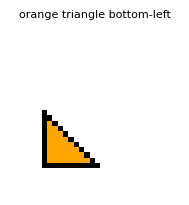

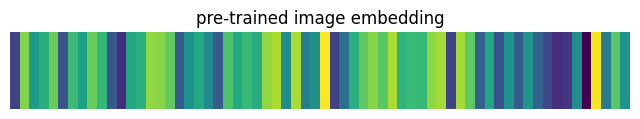

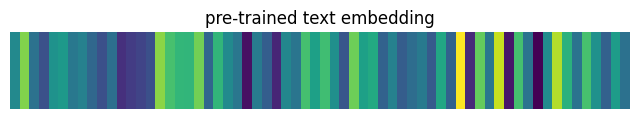

In [338]:
img_enc.eval(); text_enc.eval()
with torch.no_grad():
  random_idx = random.randrange(len(full_ds))
  sample_img, sample_toks, sample_cap = full_ds[random_idx]
  sample_img = sample_img.unsqueeze(0).to(device)
  sample_toks = sample_toks.unsqueeze(0).to(device)
  pre_train_img_emb = img_enc(sample_img).squeeze(0).cpu().numpy()
  pre_train_txt_emb = text_enc(sample_toks).squeeze(0).cpu().numpy()

  print(f"sample image and caption for embeddings visualization : '{sample_cap}' ")
  show_image(sample_img.squeeze(0), title= sample_cap)

def plot_embedding(embedding, title):
   plt.figure(figsize = (8, 1))
   plt.imshow(embedding.reshape(1, -1), aspect='auto', cmap= 'viridis')
   plt.title(title)
   plt.axis('off')
   plt.show()

plot_embedding(pre_train_img_emb, 'pre-trained image embedding')
plot_embedding(pre_train_txt_emb, 'pre-trained text embedding')

training loop

In [339]:
best_val = float("inf")

def clip_loss(img_emb, txt_emb, temperature = TEMPERATURE):
  logits = img_emb @ txt_emb.T / temperature
  targets = torch.arange(img_emb.size(0), device= img_emb.device)
  loss_i = F.cross_entropy(logits, targets)
  loss_t = F.cross_entropy(logits.T, targets)
  return ((loss_i + loss_t)/ 2.0)

for epoch in range(1, EPOCHS+1):
  img_enc.train();  text_enc.train()
  total = 0.0

  for img, toks, _ in train_loader:
    img = img.to(device); toks = toks.to(device)
    optimizer.zero_grad(set_to_none = True)
    ie = img_enc(img); te = text_enc(toks)
    loss = clip_loss(ie, te)
    loss.backward()
    optimizer.step()
    total += loss.item()*img.size(0)

  train_loss = total / len(train_ds)

  img_enc.eval(); text_enc.eval()
  with torch.no_grad():
    vtotal, n = 0.0, 0
    for img, toks, _ in val_loader:
      img = img.to(device); toks = toks.to(device)
      vtotal += clip_loss(img_enc(img), text_enc(toks)).item()*img.size(0)
      n += img.size(0)

    val_loss = vtotal/n

  print(f"epoch : {epoch} train: {train_loss:.4f} val : {val_loss:.4f}")
  best_val = min(best_val, val_loss)

epoch : 1 train: 2.5249 val : 2.3986
epoch : 2 train: 2.3746 val : 1.9275
epoch : 3 train: 1.4651 val : 0.9232
epoch : 4 train: 0.7387 val : 0.7330
epoch : 5 train: 0.6341 val : 0.5984
epoch : 6 train: 0.4583 val : 0.5332
epoch : 7 train: 0.4240 val : 0.4611
epoch : 8 train: 0.4147 val : 0.9136
epoch : 9 train: 0.5324 val : 0.4394
epoch : 10 train: 0.3329 val : 0.3509
epoch : 11 train: 0.2326 val : 0.2909
epoch : 12 train: 0.1825 val : 0.2858
epoch : 13 train: 0.2019 val : 0.4018
epoch : 14 train: 0.1782 val : 0.3157
epoch : 15 train: 0.2005 val : 0.2902
epoch : 16 train: 0.1613 val : 0.2685
epoch : 17 train: 0.1527 val : 0.2619
epoch : 18 train: 0.1324 val : 0.2873
epoch : 19 train: 0.1571 val : 0.3231
epoch : 20 train: 0.1347 val : 0.1991
epoch : 21 train: 0.1607 val : 0.2060
epoch : 22 train: 0.1590 val : 0.2227
epoch : 23 train: 0.1053 val : 0.2453
epoch : 24 train: 0.1157 val : 0.2235
epoch : 25 train: 0.1192 val : 0.2234
epoch : 26 train: 0.1087 val : 0.1881
epoch : 27 train: 0.1

display embedding after training

sample image and caption for embedding : 'orange triangle bottom-left'


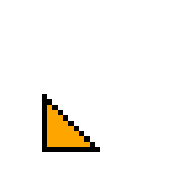

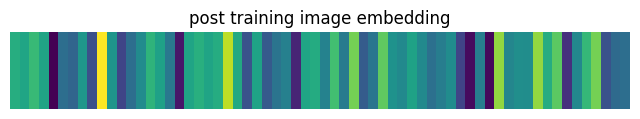

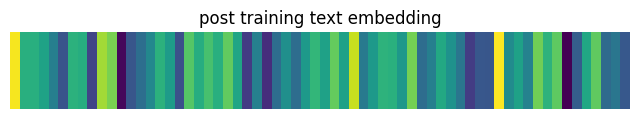

In [342]:
img_enc.eval(); text_enc.eval()
with torch.no_grad():
  sample_img, sample_toks, sample_cap = full_ds[random_idx]
  sample_img = sample_img.unsqueeze(0).to(device)
  sample_toks = sample_toks.unsqueeze(0).to(device)

  post_train_img_emb = img_enc(sample_img).squeeze(0).cpu().numpy()
  post_train_txt_emb = text_enc(sample_toks).squeeze(0).cpu().numpy()

  print(f"sample image and caption for embedding : '{sample_cap}'")

  show_image(sample_img.squeeze(0).cpu())

  plot_embedding(post_train_img_emb, "post training image embedding")
  plot_embedding(post_train_txt_emb, "post training text embedding")
